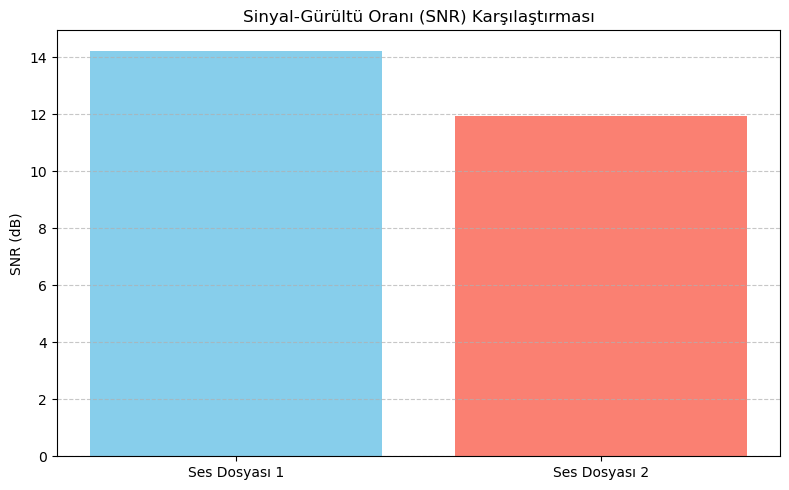

In [46]:
# Gerekli kütüphanelerin içe aktarılması
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display

# İşlenecek ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# İşlenecek ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# Sinyal-Gürültü Oranı (SNR) hesaplama fonksiyonu
def calculate_snr(y, sr):
# Frame uzunluğu: 50ms
    f_len = int(sr * 0.05)
    hop = f_len // 2
    
# RMS (karekök ortalama) hesaplama
    rms = librosa.feature.rms(y=y, frame_length=f_len, hop_length=hop)[0]
    
# Gürültü olarak kabul edilecek eşik: RMS'in %20 altı
    thr = np.percentile(rms, 20)
    n_idx = rms < thr
    
# Zaman vektörü
    times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop)
    
# Gürültü sinyalini sıfırdan oluşturma
    n_sig = np.zeros_like(y)
    for i, t in enumerate(times):
        s = librosa.time_to_samples(t, sr=sr)
        e = librosa.time_to_samples(t + 0.05, sr=sr)
        if n_idx[i]: n_sig[s:e] = y[s:e]
    
# Sinyal gücü ve gürültü gücü hesaplama
    p_sig = np.mean(y**2)
    p_noise = np.mean(n_sig**2)
    
# Gürültü yoksa sonsuz SNR döndür
    if p_noise == 0: return np.inf
    
# SNR hesaplama (dB cinsinden)
    return 10 * np.log10(p_sig / p_noise)

# Ses dosyalarını yükleme ve SNR hesaplama
y1, sr1 = librosa.load(file_1, sr=None)
y2, sr2 = librosa.load(file_2, sr=None)
snr1 = calculate_snr(y1, sr1)
snr2 = calculate_snr(y2, sr2)

# Görsel ayarlamalar
plt.figure(figsize=(8,5))
plt.bar([label_1, label_2], [snr1, snr2], color=['skyblue', 'salmon'])
plt.title("Sinyal-Gürültü Oranı (SNR) Karşılaştırması")
plt.ylabel("SNR (dB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()